In [8]:
# Cellule 7: ANALYSE DES OUTLIERS (valeurs aberrantes)
print("❓ QUESTION 2: Y a-t-il des outliers significatifs?")
print("="*60)

# Sélectionner uniquement les colonnes numériques
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"📊 Variables numériques analysées: {len(numerical_cols)}")
print(numerical_cols)

❓ QUESTION 2: Y a-t-il des outliers significatifs?
📊 Variables numériques analysées: 17
['Age', 'BMI', 'Height', 'Weight', 'Length_of_Stay', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'CRP']


📊 Création des boxplots...


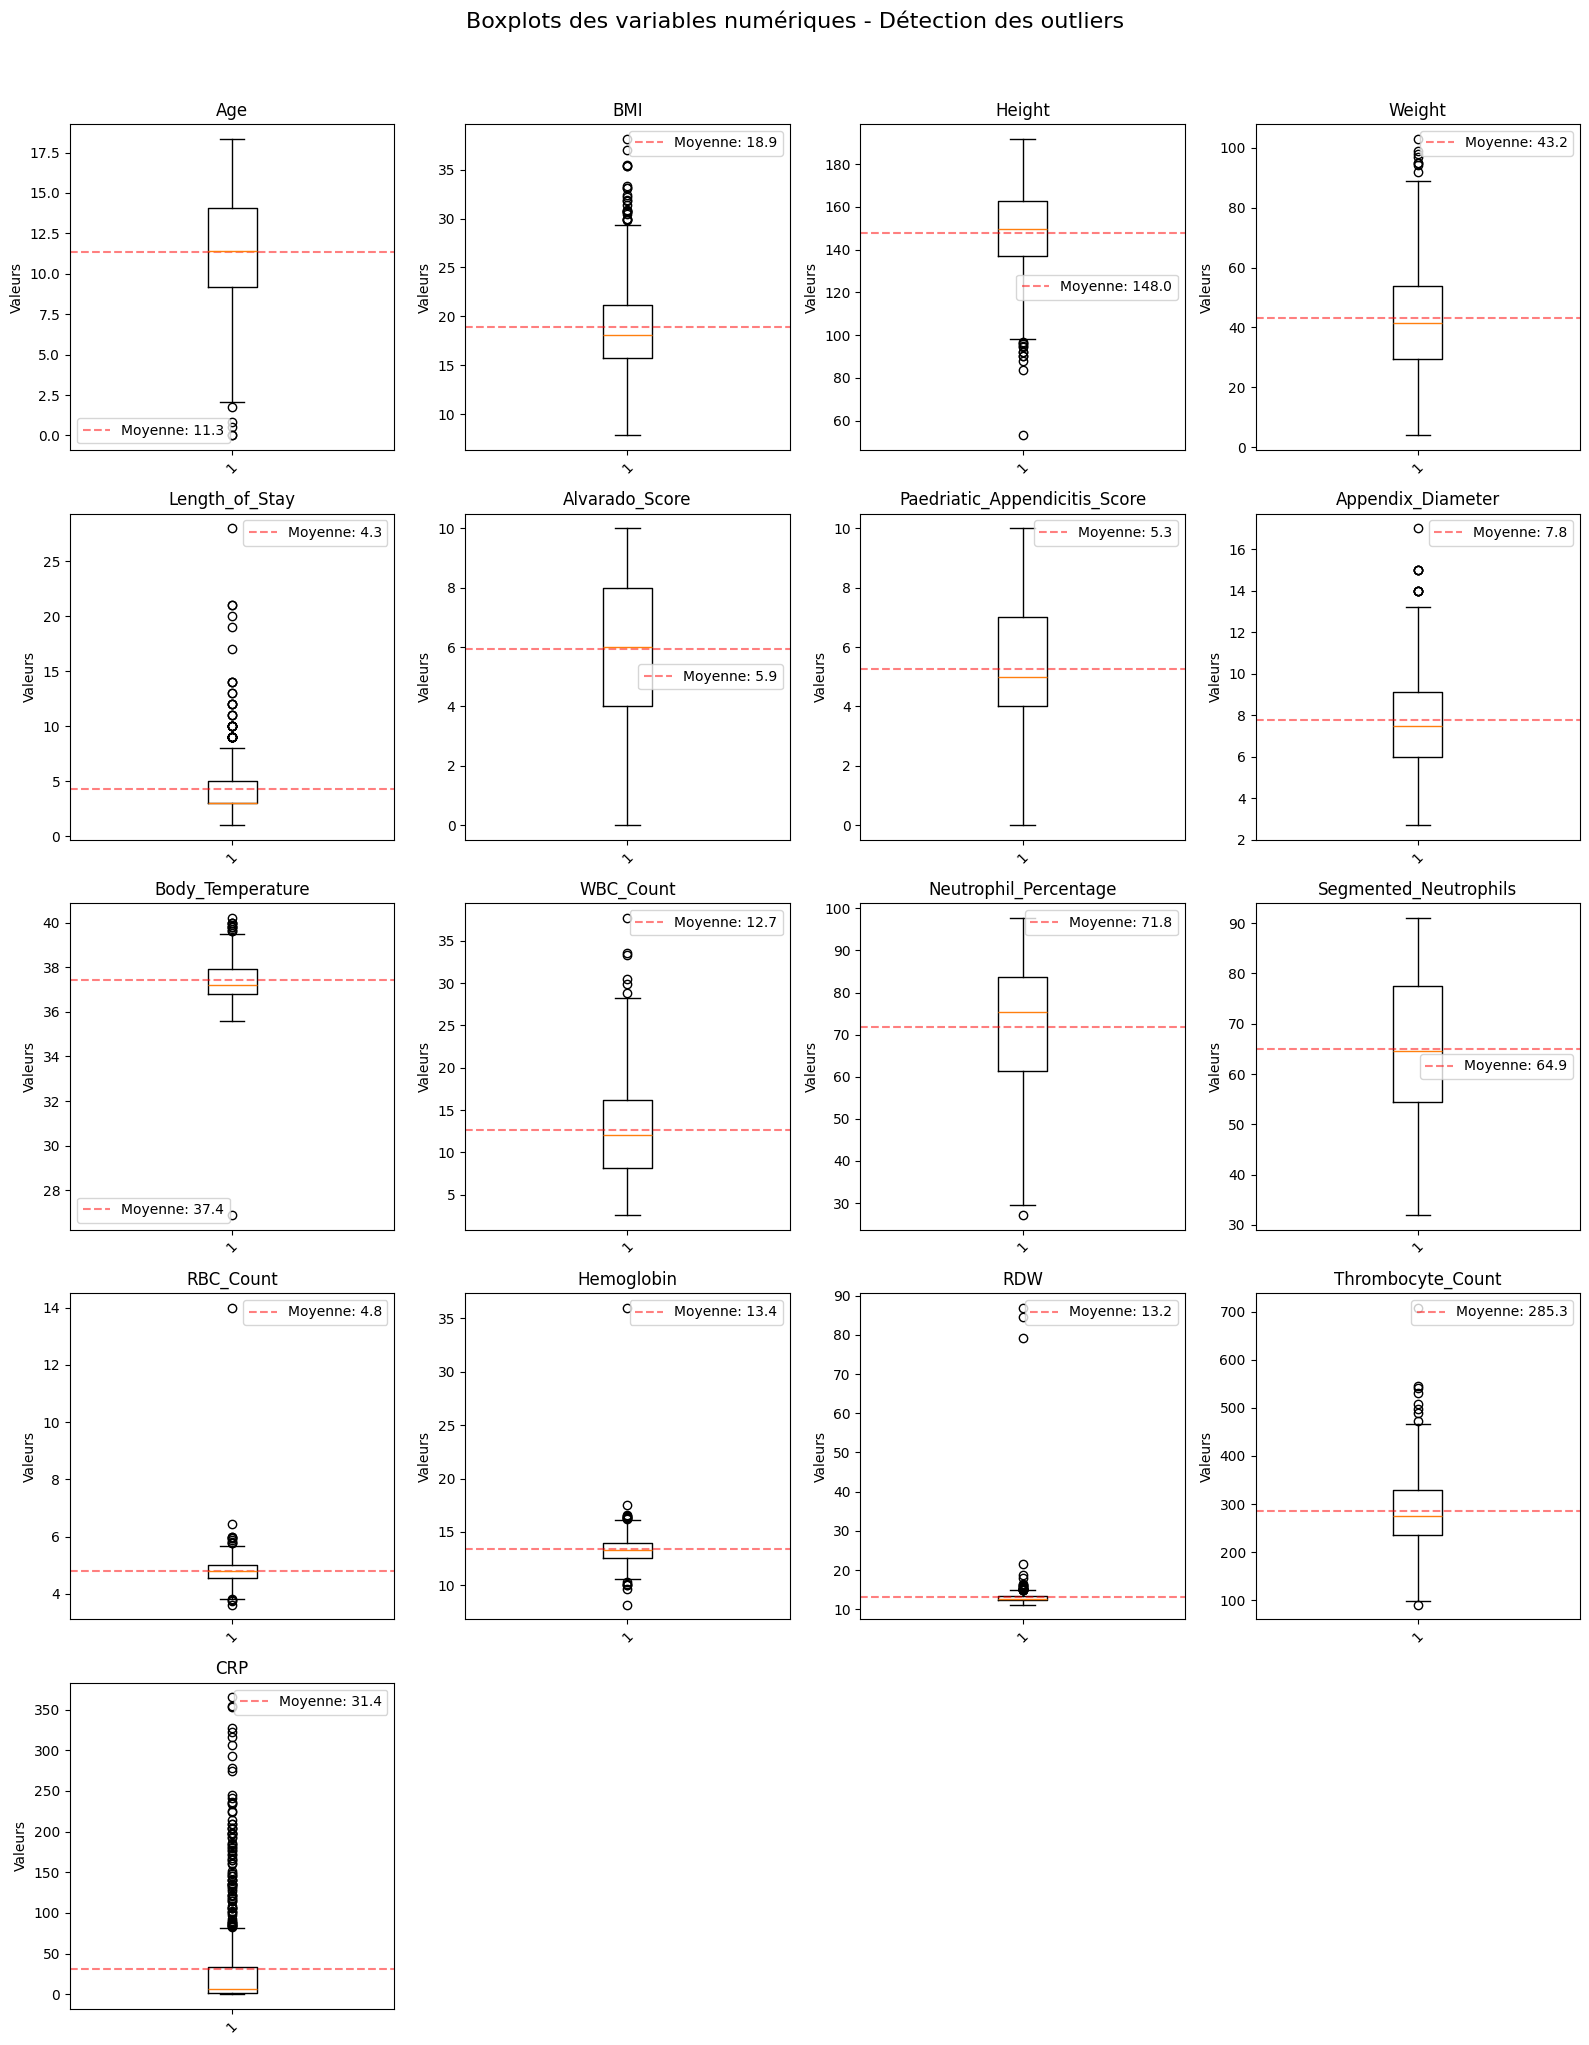

In [9]:
# Cellule 8: Visualisation des boxplots pour détecter les outliers
print("📊 Création des boxplots...")

# Calculer le nombre de lignes nécessaires pour les graphiques
n_cols = len(numerical_cols)
n_rows = (n_cols // 4) + 1

# Créer les graphiques
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 4))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    # Boxplot
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel('Valeurs')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Ajouter une ligne horizontale pour la moyenne
    mean_val = df[col].mean()
    axes[idx].axhline(y=mean_val, color='r', linestyle='--', alpha=0.5, label=f'Moyenne: {mean_val:.1f}')
    axes[idx].legend()

# Cacher les subplots vides
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots des variables numériques - Détection des outliers', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

📊 QUANTIFICATION DES OUTLIERS (Méthode IQR)
⚠️ 14 variables ont des outliers

Variables avec le plus d'outliers:
                   nombre  pourcentage
CRP                  85.0        10.87
Length_of_Stay       44.0         5.63
RDW                  23.0         2.94
BMI                  23.0         2.94
Hemoglobin           16.0         2.05
RBC_Count            14.0         1.79
Body_Temperature     12.0         1.53
Height               12.0         1.53
Appendix_Diameter    10.0         1.28
Thrombocyte_Count     9.0         1.15


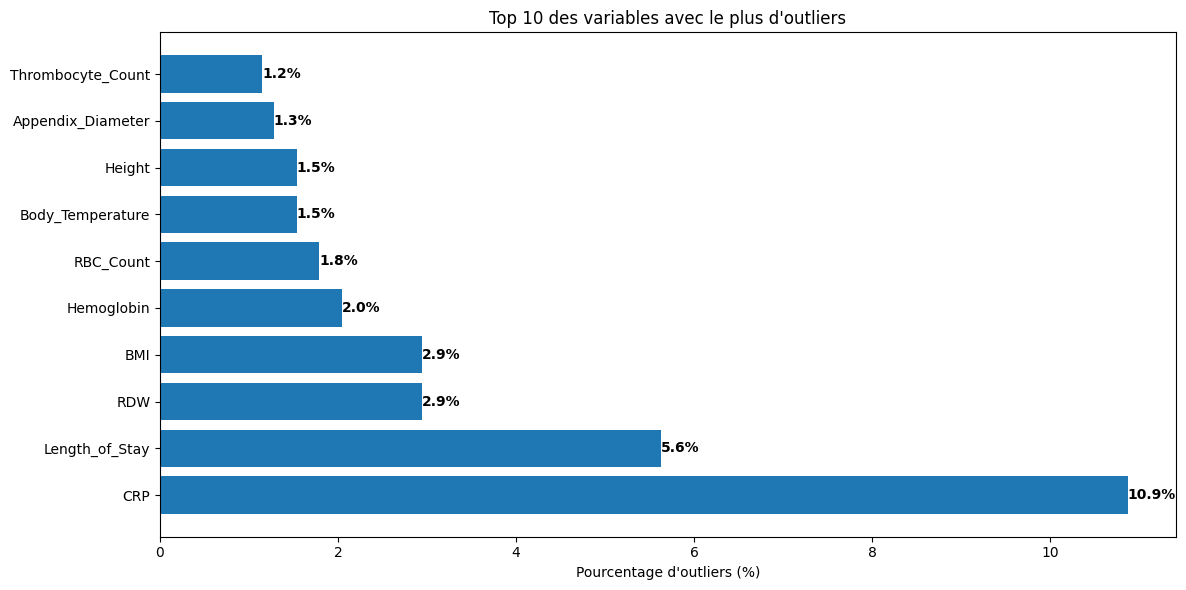

In [10]:
# Cellule 9: Quantification des outliers avec la méthode IQR
print("📊 QUANTIFICATION DES OUTLIERS (Méthode IQR)")
print("="*50)

outliers_dict = {}

for col in numerical_cols:
    # Calculer Q1, Q3 et IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Définir les bornes
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Compter les outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_dict[col] = {
        'nombre': len(outliers),
        'pourcentage': (len(outliers) / len(df) * 100),
        'borne_inf': lower_bound,
        'borne_sup': upper_bound,
        'min_valeur': df[col].min(),
        'max_valeur': df[col].max()
    }

# Créer un DataFrame pour afficher les résultats
outliers_df = pd.DataFrame(outliers_dict).T
outliers_df = outliers_df[outliers_df['nombre'] > 0].sort_values('nombre', ascending=False)

if len(outliers_df) > 0:
    print(f"⚠️ {len(outliers_df)} variables ont des outliers\n")
    print("Variables avec le plus d'outliers:")
    print(outliers_df[['nombre', 'pourcentage']].head(10).round(2))
    
    # Graphique des top outliers
    plt.figure(figsize=(12, 6))
    top_outliers = outliers_df.head(10)
    bars = plt.barh(top_outliers.index, top_outliers['pourcentage'])
    plt.xlabel('Pourcentage d\'outliers (%)')
    plt.title('Top 10 des variables avec le plus d\'outliers')
    
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
                ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ AUCUN outlier détecté dans les variables numériques!")

In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("🔬 TEST DE VÉRIFICATION - ANALYSE DES OUTLIERS")
print("="*60)

# ============================================
# TEST 1: CRÉATION D'UN DATASET FACTICE
# ============================================
print("\n📌 TEST 1: Création d'un dataset test")
print("-"*40)

# Créer des données normales
np.random.seed(42)  # Pour avoir les mêmes résultats à chaque exécution
donnees_normales = np.random.normal(100, 15, 20)  # 20 valeurs normales

# Ajouter des outliers volontairement
outliers_volontaires = [30, 35, 180, 190, 200, 250, 20, 15]

# Combiner
toutes_donnees = np.concatenate([donnees_normales, outliers_volontaires])

# Créer un DataFrame
df_test = pd.DataFrame({'valeur_test': toutes_donnees})

print(f"✅ Dataset créé avec {len(df_test)} lignes")
print(f"   - Valeurs normales: {len(donnees_normales)}")
print(f"   - Outliers ajoutés: {len(outliers_volontaires)}")
print(f"   - Moyenne: {df_test['valeur_test'].mean():.1f}")
print(f"   - Min: {df_test['valeur_test'].min():.0f}")
print(f"   - Max: {df_test['valeur_test'].max():.0f}")

# ============================================
# TEST 2: TEST DE DÉTECTION IQR
# ============================================
print("\n📌 TEST 2: Test de la méthode IQR")
print("-"*40)

def detecter_outliers_iqr(data):
    """Fonction pour détecter les outliers avec IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    borne_inf = Q1 - 1.5 * IQR
    borne_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data < borne_inf) | (data > borne_sup)]
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'borne_inf': borne_inf,
        'borne_sup': borne_sup,
        'outliers': outliers,
        'nb_outliers': len(outliers),
        'pourcentage': (len(outliers) / len(data)) * 100
    }

# Tester la fonction
resultat_iqr = detecter_outliers_iqr(df_test['valeur_test'])

print(f"Q1 (25%): {resultat_iqr['Q1']:.1f}")
print(f"Q3 (75%): {resultat_iqr['Q3']:.1f}")
print(f"IQR: {resultat_iqr['IQR']:.1f}")
print(f"Bornes: [{resultat_iqr['borne_inf']:.1f}, {resultat_iqr['borne_sup']:.1f}]")
print(f"Outliers détectés: {resultat_iqr['nb_outliers']} ({resultat_iqr['pourcentage']:.1f}%)")

# VÉRIFICATION: Est-ce que nos outliers volontaires sont détectés?
outliers_detectes = resultat_iqr['outliers'].values
print("\n🔍 Vérification:")
print(f"   Outliers volontaires: {sorted(outliers_volontaires)}")
print(f"   Outliers détectés: {sorted(outliers_detectes)}")

if set(outliers_volontaires).issubset(set(outliers_detectes)):
    print("   ✅ SUCCÈS: Tous les outliers volontaires sont détectés!")
else:
    print("   ❌ ÉCHEC: Certains outliers ne sont pas détectés")
    non_detectes = set(outliers_volontaires) - set(outliers_detectes)
    print(f"      Non détectés: {non_detectes}")

🔬 TEST DE VÉRIFICATION - ANALYSE DES OUTLIERS

📌 TEST 1: Création d'un dataset test
----------------------------------------
✅ Dataset créé avec 28 lignes
   - Valeurs normales: 20
   - Outliers ajoutés: 8
   - Moyenne: 102.5
   - Min: 15
   - Max: 250

📌 TEST 2: Test de la méthode IQR
----------------------------------------
Q1 (25%): 83.3
Q3 (75%): 110.2
IQR: 26.9
Bornes: [43.0, 150.4]
Outliers détectés: 8 (28.6%)

🔍 Vérification:
   Outliers volontaires: [15, 20, 30, 35, 180, 190, 200, 250]
   Outliers détectés: [np.float64(15.0), np.float64(20.0), np.float64(30.0), np.float64(35.0), np.float64(180.0), np.float64(190.0), np.float64(200.0), np.float64(250.0)]
   ✅ SUCCÈS: Tous les outliers volontaires sont détectés!
